In [17]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [18]:
from qells import qell_s_spherical_vectorized, qell_k_spherical
from Qell_2pcf import Ql_2pcf

# A ball in the Sky

In [19]:
ells = [0, 2]

In [20]:
radius = 100.

## A ball on a mesh

In [21]:
box, lmax, pmesh = 30. * radius, 2, 8
box_size = 3*[box]
mesh_size = 3*[2**pmesh]
kf, knq = 2*np.pi/box, np.pi * 2**pmesh/box
print (box_size, mesh_size, kf, knq)

[3000.0, 3000.0, 3000.0] [256, 256, 256] 0.0020943951023931952 0.268082573106329


### Mesh grids and real spherical harmonics

from `pmesh` interfaced through `pypower`: https://github.com/cosmodesi/pypower  
PZ: there is a different coordinate conventions than `pmesh` that I could not make sense of

In [22]:
from pypower import ArrayMesh, MeshFFTPower

In [23]:
def get_grid(mesh_size, box_size, lmax=lmax):

    # a dummy pmesh class
    rfield = ArrayMesh(np.ones(mesh_size), box_size) 
    cfield = rfield.r2c()
    
    def _safe_divide(num, denom):
        with np.errstate(divide='ignore', invalid='ignore'):
            toret = num / denom
        toret[denom == 0.] = 0.
        return toret

    def _transform_rslab(rslab, boxsize, convention='pmesh'):
        if convention == 'PyPower': 
            # We do not use the same conventions as pmesh:
            # rslab < 0 is sent back to [boxsize/2, boxsize]
            toret = []
            for ii, rr in enumerate(rslab):
                mask = rr < 0.
                rr = rr.copy()
                rr[mask] += boxsize[ii]
                toret.append(rr)
            return toret
        elif convention == 'pmesh':
            return rslab
    
    # The real-space grid
    offset = 0.5 * np.array(box_size) / np.array(mesh_size).astype('f8')
    xhat = [xx.real.astype('f8') + offset[ii] for ii, xx in enumerate(_transform_rslab(rfield.slabs.optx, box_size))]
    xnorm = np.sqrt(sum(xx**2 for xx in xhat))
    xhat = [_safe_divide(xx, xnorm) for xx in xhat]
    
    # The Fourier-space grid
    khat = [kk.real.astype('f8') for kk in cfield.slabs.optx]
    knorm = np.sqrt(sum(kk**2 for kk in khat))
    khat = [_safe_divide(kk, knorm) for kk in khat]
    
    return xnorm, xhat, knorm, khat

xnorm, xhat, knorm, khat = get_grid(mesh_size, box_size)
print (xnorm.shape, np.array(khat).shape, knorm.shape, np.array(khat).shape)

(256, 256, 256) (3, 256, 129, 256) (256, 129, 256) (3, 256, 129, 256)


mean =  0.00015544891357421875
min =  0.0
max =  1.0


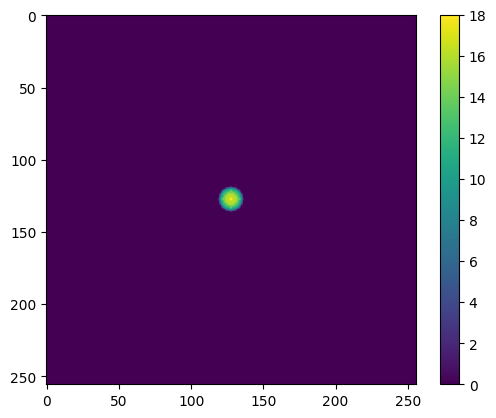

In [24]:
def get_ball(xnorm, radius=radius):
    return 1. * (np.abs(xnorm) <= radius)

xlist = np.linspace(-box/2., box/2.-box/2**pmesh, 2**pmesh)
xlist += 0.5 * box/2**pmesh
xnorm_ = np.sum(np.array(np.meshgrid(xlist, xlist, xlist))**2, axis = 0)**.5

ball = get_ball(xnorm_)
ws = ArrayMesh(ball, box_size)

print("mean = ", ws.value.mean())
print("min = ", ws.value.min())
print("max = ", ws.value.max())

plt.imshow(ws.preview(axes=[0,1]))
plt.colorbar()

### $Q_\ell(k)$: power spectrum of the skyball

In [25]:
# edges
eps = 1e-16
mu = np.linspace(-1, 1, 2, endpoint=True)
kk = np.arange(kf, knq-eps, kf)
ss = np.arange(box/2**pmesh, box/2.-eps, box/2**pmesh)
edges_s = [ss, mu]
edges_k = [kk, mu]

In [26]:
poles_z = MeshFFTPower(ws, edges=kk, ells=ells, los='z').poles # this is what we should use to compare Domi's fm
poles = MeshFFTPower(ws, edges=kk, ells=ells, los='endpoint').poles # this is what we should use for real curved sky

In [27]:
kk = poles.k
qk_fm_z = poles_z(ell=ells, complex=False)
qk_fm_z /= qk_fm_z[0,0]

In [28]:
kk = poles.k
qk_fm = poles(ell=ells, complex=False)
qk_fm /= qk_fm[0,0]

In [29]:
qk_domi = np.array([qell_k_spherical_wrapper(ell, kk, radius) for ell in ells])
qk_domi /= qk_domi[0,0]

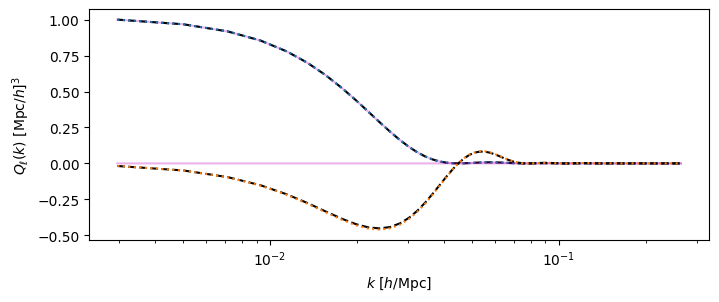

In [33]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells):
    plt.plot(kk, qk_fm_z[i], 'm', alpha=0.3, label=r'fm $\ell=%s$' % ell)
    plt.plot(kk, qk_fm[i], '--k', label=r'fm $\ell=%s$' % ell)
    plt.plot(kk, qk_domi[i], ':C%s' % i, label=r'Domi $\ell=%s$' % ell)
plt.ylabel(r'$Q_\ell(k) \ [{\rm Mpc}/h]^3$')
plt.xlabel(r'$k \ [h/{\rm Mpc}]$')
plt.xscale('log')

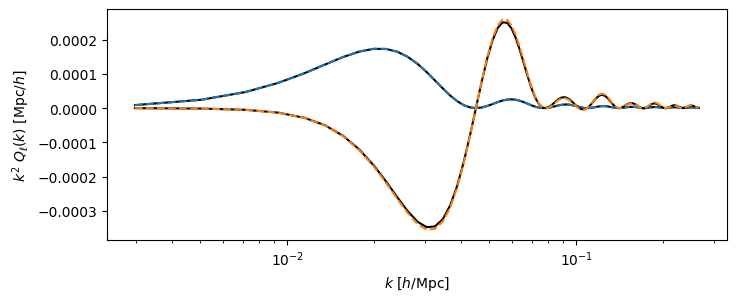

In [31]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells):
    plt.plot(kk, kk**2 * qk_fm[i], 'k', label=r'fm $\ell=%s$' % ell)
    plt.plot(kk, kk**2 * qk_domi[i], '--C%s' % i, label=r'Domi $\ell=%s$' % ell)
plt.ylabel(r'$k^2 \ Q_\ell(k) \ [{\rm Mpc}/h]$')
plt.xlabel(r'$k \ [h/{\rm Mpc}]$')
plt.xscale('log')

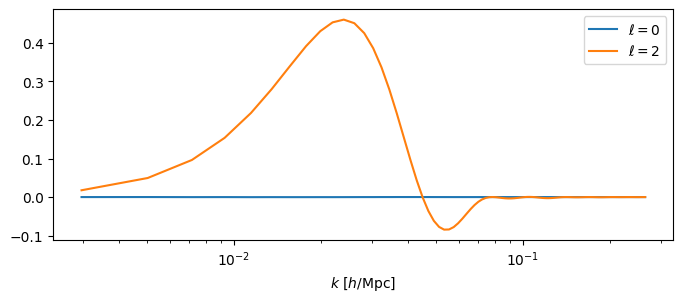

In [16]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): plt.plot(kk, (qk_fm[i]-qk_domi[i])/qk_fm[0,0], 'C%s' % i, label=r'$\ell=%s$' % ell)
plt.xlabel(r'$k \ [h/{\rm Mpc}]$')
plt.xscale('log')
plt.legend()

### $Q_\ell(s)$: correlation function of the skyball

In [16]:
ss = np.geomspace(1e-4, 1e4, 1024 * 16) # configuration space separation for FFTlog
ss = ss[ss > 0.1]

qs_kevin = np.array([[Ql_2pcf(ell, s, radius) for s in ss] for ell in ells])
qs_kevin /= qs_kevin[0,0]
qs_domi = np.array([qell_s_spherical_vectorized(ell, ss, radius) for ell in ells]) # PZ: is this the correct sign?
qs_domi /= qs_domi[0,0]
print (qs_kevin.shape, qs_domi.shape)

(2, 10240) (2, 10240)


/Users/pierre/Documents/github/fkpwin/pre/sphere/Qell_2pcf.py:22: RuntimeWarning: invalid value encountered in log
  term2 = -0.0625*((x*(-2*R + x)*(-6*R**4 - 6*R**3*x + 13*R**2*x**2 + 2*R*x**3 + 7*x**4))/12. + (R**2 - x**2)**3*np.log(-1 + x/R))/x**3
/Users/pierre/Documents/github/fkpwin/pre/sphere/Qell_2pcf.py:21: RuntimeWarning: invalid value encountered in log
  term1 = -0.0625*((x*(-2*R + x)*(-6*R**4 - 6*R**3*x + 13*R**2*x**2 + 2*R*x**3 + 7*x**4))/12. + (R**2 - x**2)**3*np.log(1 - x/R))/x**3


In [17]:
from fftlog.sbt import SBT
import importlib, fftlog.sbt
importlib.reload(fftlog.sbt)

<module 'fftlog.sbt' from '/Users/pierre/Documents/github/fftlog/fftlog/sbt.py'>

In [24]:
sbt = SBT(ells=ells)
sbt.set_f2c(ss, kmin=1e-5, kmax=1e3, bias=-2.1, NFFT=256, extrap='padding')

In [25]:
qk_ = np.array([qell_k_spherical_wrapper(ell, sbt.fft.x, radius) for ell in ells]) # this is slow...

In [26]:
qs_fm = sbt.get_transform(sbt.fft.x, qk_) # I cheat here, since qk_fm ~ qk_domi, I use qk_domi
qs_fm /= qs_fm[0,0]

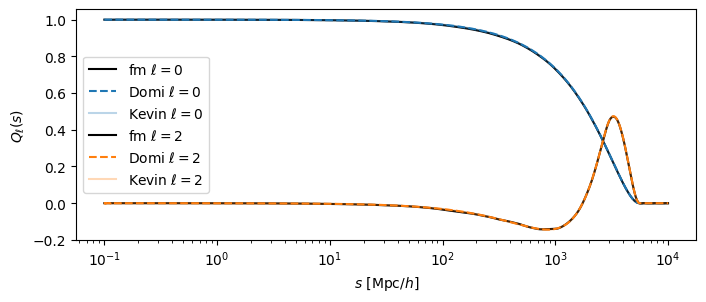

In [27]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): 
    plt.plot(ss, qs_fm[i], 'k', label=r'fm $\ell=%s$' % ell)
    plt.plot(ss, qs_domi[i], '--C%s' % i, label=r'Domi $\ell=%s$' % ell)
    plt.plot(ss, qs_kevin[i], 'C%s' % i, alpha=0.3, label=r'Kevin $\ell=%s$' % ell)
plt.ylabel(r'$Q_\ell(s)$')
plt.xlabel(r'$s \ [{\rm Mpc}/h]$')
plt.xscale('log')
plt.legend()

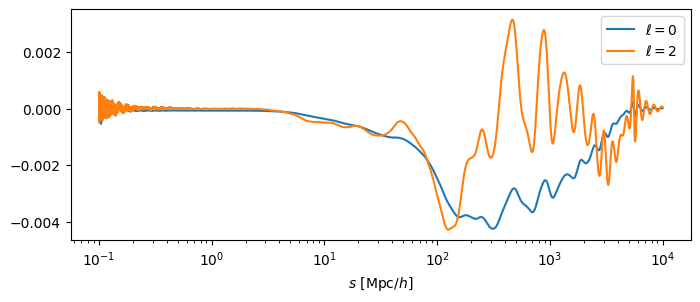

In [28]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): plt.plot(ss, (qs_fm[i]-qs_domi[i])/qs_domi[0,0], 'C%s' % i, label=r'$\ell=%s$' % ell)
plt.xlabel(r'$s \ [{\rm Mpc}/h]$')
plt.xscale('log')
plt.legend()

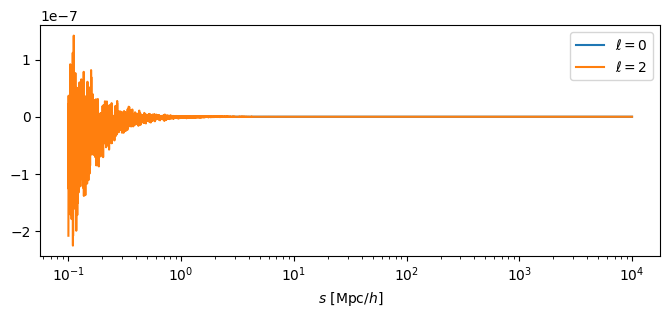

In [29]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): plt.plot(ss, (qs_kevin[i]-qs_domi[i])/qs_domi[0,0], 'C%s' % i, label=r'$\ell=%s$' % ell)
plt.xlabel(r'$s \ [{\rm Mpc}/h]$')
plt.xscale('log')
plt.legend()

The theoretical $Q_\ell(s)$ are endpoint los. 